# Green Computer Vision — Kaggle Notebook

This notebook is part of the project:

**Green Computer Vision: Comparing Accuracy and Efficiency in Deep Image Classification**

Datasets:
- **PlantDoc**: plant disease classification / sustainable agriculture
- **TrashNet**: waste classification / recycling

Models:
- Custom CNN
- MobileNetV3
- EfficientNet-B0
- ResNet-50

All outputs are saved under:

`/kaggle/working/green_cv_results/`


# RQ4 Notebook — Deployment Suitability

This notebook trains and evaluates all models on PlantDoc and TrashNet, then saves:

- `rq4_deployment_suitability.csv`
- `rq4_deployment_suitability_radar.pdf`

The main focus is suitability for edge or low-resource deployment.


In [1]:

# ============================================================
# CONFIGURATION
# ============================================================
# Run this notebook on Kaggle.
# Add PlantDoc and TrashNet datasets to the Kaggle notebook input panel.
#
# If auto-detection fails, manually set the paths below.
# Example:
# PLANTDOC_ROOT = "/kaggle/input/plant-doc-dataset/PlantDoc-Dataset"
# TRASHNET_ROOT = "/kaggle/input/trashnet/dataset-resized"
# ============================================================

PLANTDOC_ROOT = "/kaggle/input/datasets/abdulhasibuddin/plant-doc-dataset/PlantDoc-Dataset"
TRASHNET_ROOT = "/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized"

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 8                 # Increase to 15-30 for final experiments
LEARNING_RATE = 1e-4
SEED = 42

# Set to True for quick debugging. For final results, keep False.
QUICK_TEST = False
QUICK_TEST_SAMPLES_PER_DATASET = 600

# For transfer learning models
USE_IMAGENET_WEIGHTS = True
FREEZE_BACKBONE = True

# Energy estimation setting
# Replace this with measured device power if you have actual wattmeter/NVML values.
INFERENCE_POWER_WATTS = 5.0
CARBON_INTENSITY_KG_PER_KWH = 0.42

RESULTS_DIR = "/kaggle/working/green_cv_results"


In [2]:

# ============================================================
# IMPORTS AND REPRODUCIBILITY
# ============================================================
import os
import time
import json
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

RESULTS_DIR = Path(RESULTS_DIR)
TABLE_DIR = RESULTS_DIR / "tables"
FIGURE_DIR = RESULTS_DIR / "figures"
MODEL_DIR = RESULTS_DIR / "models"

for d in [RESULTS_DIR, TABLE_DIR, FIGURE_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

# ============================================================
# DATASET DISCOVERY AND LOADING
# ============================================================
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def count_images(path):
    path = Path(path)
    return sum(1 for p in path.rglob("*") if p.suffix.lower() in IMAGE_EXTS)

def class_subdirs(path):
    path = Path(path)
    return sorted([p for p in path.iterdir() if p.is_dir() and count_images(p) > 0])

def looks_like_class_root(path):
    path = Path(path)
    subs = class_subdirs(path)
    return len(subs) >= 2

def auto_detect_dataset_root(keyword):
    base = Path("/kaggle/input")
    if not base.exists():
        raise FileNotFoundError("This notebook is designed for Kaggle. /kaggle/input was not found.")

    candidates = []
    for p in base.rglob("*"):
        if not p.is_dir():
            continue

        name_score = 10 if keyword.lower() in str(p).lower() else 0
        image_count = count_images(p)
        if image_count == 0:
            continue

        has_split = any((p / s).exists() for s in ["train", "Train", "training", "test", "Test", "valid", "val"])
        is_class_root = looks_like_class_root(p)
        if has_split or is_class_root:
            class_count = len(class_subdirs(p))
            score = name_score + image_count / 1000 + class_count
            if has_split:
                score += 5
            candidates.append((score, str(p), image_count, class_count, has_split))

    candidates = sorted(candidates, reverse=True)
    if not candidates:
        raise FileNotFoundError(f"Could not auto-detect dataset root for keyword: {keyword}")

    print(f"\nTop candidates for {keyword}:")
    for row in candidates[:5]:
        print(row)

    return candidates[0][1]

def resolve_roots():
    global PLANTDOC_ROOT, TRASHNET_ROOT
    if PLANTDOC_ROOT is None:
        PLANTDOC_ROOT = auto_detect_dataset_root("plant")
    if TRASHNET_ROOT is None:
        # TrashNet Kaggle folders may contain 'trash', 'garbage', or 'waste'
        try:
            TRASHNET_ROOT = auto_detect_dataset_root("trash")
        except Exception:
            try:
                TRASHNET_ROOT = auto_detect_dataset_root("garbage")
            except Exception:
                TRASHNET_ROOT = auto_detect_dataset_root("waste")

    print("\nResolved dataset roots:")
    print("PlantDoc:", PLANTDOC_ROOT)
    print("TrashNet:", TRASHNET_ROOT)

def get_image_records_from_class_root(root):
    root = Path(root)
    records = []
    classes = [p.name for p in class_subdirs(root)]
    classes = sorted(classes)
    for label, cls in enumerate(classes):
        cls_dir = root / cls
        for img in cls_dir.rglob("*"):
            if img.suffix.lower() in IMAGE_EXTS:
                records.append((str(img), label, cls))
    return pd.DataFrame(records, columns=["filepath", "label", "class_name"])

def find_split_dir(root, names):
    root = Path(root)
    for n in names:
        p = root / n
        if p.exists() and p.is_dir():
            return p
    return None

def load_records_for_dataset(root, dataset_name):
    root = Path(root)

    train_dir = find_split_dir(root, ["train", "Train", "training", "Training"])
    val_dir = find_split_dir(root, ["val", "valid", "validation", "Val", "Valid", "Validation"])
    test_dir = find_split_dir(root, ["test", "Test", "testing", "Testing"])

    if train_dir is not None and looks_like_class_root(train_dir):
        train_df = get_image_records_from_class_root(train_dir)

        if val_dir is not None and looks_like_class_root(val_dir):
            val_df = get_image_records_from_class_root(val_dir)
        else:
            train_df, val_df = train_test_split(
                train_df, test_size=0.15, random_state=SEED, stratify=train_df["label"]
            )

        if test_dir is not None and looks_like_class_root(test_dir):
            test_df = get_image_records_from_class_root(test_dir)
        else:
            train_df, test_df = train_test_split(
                train_df, test_size=0.15, random_state=SEED, stratify=train_df["label"]
            )
    else:
        if not looks_like_class_root(root):
            # Try to find a lower directory that looks like the actual image class root.
            possible = []
            for p in root.rglob("*"):
                if p.is_dir() and looks_like_class_root(p):
                    possible.append((count_images(p), p))
            if not possible:
                raise ValueError(f"Could not find class folders for {dataset_name} inside {root}")
            root = sorted(possible, reverse=True)[0][1]
            print(f"Using detected class-root for {dataset_name}: {root}")

        full_df = get_image_records_from_class_root(root)
        train_df, temp_df = train_test_split(
            full_df, test_size=0.30, random_state=SEED, stratify=full_df["label"]
        )
        val_df, test_df = train_test_split(
            temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["label"]
        )

    # Align labels across splits based on class names
    all_classes = sorted(pd.concat([train_df["class_name"], val_df["class_name"], test_df["class_name"]]).unique())
    class_to_label = {c: i for i, c in enumerate(all_classes)}
    for df in [train_df, val_df, test_df]:
        df["label"] = df["class_name"].map(class_to_label).astype(int)
        df["dataset"] = dataset_name

    if QUICK_TEST:
        def sample_df(df, n):
            if len(df) <= n:
                return df
            return df.groupby("label", group_keys=False).apply(
                lambda x: x.sample(max(1, int(n * len(x) / len(df))), random_state=SEED)
            ).reset_index(drop=True)

        train_df = sample_df(train_df, QUICK_TEST_SAMPLES_PER_DATASET)
        val_df = sample_df(val_df, max(100, QUICK_TEST_SAMPLES_PER_DATASET // 4))
        test_df = sample_df(test_df, max(100, QUICK_TEST_SAMPLES_PER_DATASET // 4))

    print(f"\n{dataset_name} summary")
    print("Classes:", len(all_classes))
    print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))
    print("Class names:", all_classes[:10], "..." if len(all_classes) > 10 else "")

    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True), all_classes

def make_tf_dataset(df, num_classes, shuffle=False):
    paths = df["filepath"].values
    labels = df["label"].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def load_image(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, IMAGE_SIZE)
        img = tf.cast(img, tf.float32)
        return img, label

    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(df), 2000), seed=SEED)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

# ============================================================
# MODEL BUILDING
# ============================================================
def build_custom_cnn(num_classes):
    inputs = keras.Input(shape=(*IMAGE_SIZE, 3))
    x = layers.Rescaling(1./255)(inputs)
    x = layers.RandomFlip("horizontal")(x)
    x = layers.RandomRotation(0.08)(x)
    x = layers.RandomZoom(0.10)(x)

    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="Custom_CNN")

def build_transfer_model(model_name, num_classes):
    weights = "imagenet" if USE_IMAGENET_WEIGHTS else None
    inputs = keras.Input(shape=(*IMAGE_SIZE, 3))

    aug = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.10),
    ], name="augmentation")

    x = aug(inputs)

    if model_name == "MobileNetV3":
        preprocess = tf.keras.applications.mobilenet_v3.preprocess_input
        base = tf.keras.applications.MobileNetV3Small(
            include_top=False, weights=weights, input_shape=(*IMAGE_SIZE, 3)
        )
    elif model_name == "EfficientNet-B0":
        preprocess = tf.keras.applications.efficientnet.preprocess_input
        base = tf.keras.applications.EfficientNetB0(
            include_top=False, weights=weights, input_shape=(*IMAGE_SIZE, 3)
        )
    elif model_name == "ResNet-50":
        preprocess = tf.keras.applications.resnet50.preprocess_input
        base = tf.keras.applications.ResNet50(
            include_top=False, weights=weights, input_shape=(*IMAGE_SIZE, 3)
        )
    else:
        raise ValueError(f"Unknown model name: {model_name}")

    base.trainable = not FREEZE_BACKBONE
    x = preprocess(x)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name=model_name.replace("-", "_"))

def build_model(model_name, num_classes):
    if model_name == "Custom CNN":
        return build_custom_cnn(num_classes)
    return build_transfer_model(model_name, num_classes)

MODEL_NAMES = ["Custom CNN", "MobileNetV3", "EfficientNet-B0", "ResNet-50"]

# ============================================================
# TRAINING, EVALUATION, EFFICIENCY MEASUREMENT
# ============================================================
def evaluate_classification(model, test_ds, y_true):
    probs = model.predict(test_ds, verbose=0)
    y_pred = np.argmax(probs, axis=1)

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

def measure_latency_ms(model, test_ds, warmup_batches=2, measure_batches=10):
    # Warmup
    iterator = iter(test_ds)
    for _ in range(warmup_batches):
        try:
            batch_x, _ = next(iterator)
            _ = model.predict(batch_x, verbose=0)
        except StopIteration:
            break

    total_images = 0
    total_time = 0.0
    iterator = iter(test_ds)
    for _ in range(measure_batches):
        try:
            batch_x, _ = next(iterator)
        except StopIteration:
            break
        start = time.perf_counter()
        _ = model.predict(batch_x, verbose=0)
        end = time.perf_counter()
        total_time += (end - start)
        total_images += int(batch_x.shape[0])

    if total_images == 0:
        return np.nan
    return (total_time / total_images) * 1000

def save_model_and_get_size_mb(model, path):
    path = Path(str(path) + ".keras")

    if path.exists():
        path.unlink()

    model.save(path, include_optimizer=False)

    total_bytes = path.stat().st_size
    return total_bytes / (1024 ** 2)

def count_parameters_million(model):
    return model.count_params() / 1_000_000

def train_and_evaluate_all():
    resolve_roots()

    all_rows = []

    datasets = {
        "PlantDoc": PLANTDOC_ROOT,
        "TrashNet": TRASHNET_ROOT,
    }

    for dataset_name, root in datasets.items():
        train_df, val_df, test_df, class_names = load_records_for_dataset(root, dataset_name)
        num_classes = len(class_names)

        train_ds = make_tf_dataset(train_df, num_classes, shuffle=True)
        val_ds = make_tf_dataset(val_df, num_classes, shuffle=False)
        test_ds = make_tf_dataset(test_df, num_classes, shuffle=False)
        y_true = test_df["label"].values.astype(int)

        for model_name in MODEL_NAMES:
            print(f"\nTraining {model_name} on {dataset_name}")
            keras.backend.clear_session()
            model = build_model(model_name, num_classes)
            model.compile(
                optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                loss="sparse_categorical_crossentropy",
                metrics=["accuracy"]
            )

            callbacks = [
                keras.callbacks.EarlyStopping(
                    monitor="val_accuracy",
                    patience=3,
                    restore_best_weights=True
                )
            ]

            history = model.fit(
                train_ds,
                validation_data=val_ds,
                epochs=EPOCHS,
                callbacks=callbacks,
                verbose=1
            )

            metrics = evaluate_classification(model, test_ds, y_true)
            latency_ms = measure_latency_ms(model, test_ds)

            safe_model_name = model_name.replace(" ", "_").replace("-", "_")
            save_path = MODEL_DIR / f"{dataset_name}_{safe_model_name}"
            size_mb = save_model_and_get_size_mb(model, save_path)
            params_m = count_parameters_million(model)

            energy_per_image_j = INFERENCE_POWER_WATTS * (latency_ms / 1000.0)
            energy_per_image_mj = energy_per_image_j * 1000.0
            energy_10k_kwh = (energy_per_image_j * 10000) / 3_600_000
            co2e_10k_kg = energy_10k_kwh * CARBON_INTENSITY_KG_PER_KWH

            row = {
                "Dataset": dataset_name,
                "Model": model_name,
                **metrics,
                "Parameters_M": params_m,
                "Model_Size_MB": size_mb,
                "Latency_ms_per_image": latency_ms,
                "Inference_Power_Watts": INFERENCE_POWER_WATTS,
                "Energy_per_image_mJ": energy_per_image_mj,
                "Energy_per_10k_inferences_kWh": energy_10k_kwh,
                "CO2e_per_10k_inferences_kg": co2e_10k_kg,
                "Epochs_configured": EPOCHS,
                "Epochs_trained": len(history.history["loss"]),
                "Num_classes": num_classes,
                "Train_images": len(train_df),
                "Validation_images": len(val_df),
                "Test_images": len(test_df),
            }
            print(row)
            all_rows.append(row)

            interim = pd.DataFrame(all_rows)
            interim.to_csv(TABLE_DIR / "all_model_results_interim.csv", index=False)

    results = pd.DataFrame(all_rows)
    results.to_csv(TABLE_DIR / "all_model_results.csv", index=False)
    return results

def load_or_run_results():
    results_path = TABLE_DIR / "all_model_results.csv"
    if results_path.exists():
        print(f"Loading cached results from {results_path}")
        return pd.read_csv(results_path)
    return train_and_evaluate_all()

# ============================================================
# PLOTTING SETTINGS
# ============================================================
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

def save_current_figure(name):
    pdf_path = FIGURE_DIR / f"{name}.pdf"
    png_path = FIGURE_DIR / f"{name}.png"
    plt.tight_layout()
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, bbox_inches="tight")
    print("Saved figure:", pdf_path)
    print("Saved preview PNG:", png_path)
    plt.show()


2026-06-03 12:39:18.076476: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780490358.271442      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780490358.324738      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780490358.784250      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780490358.784299      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780490358.784302      23 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]



Resolved dataset roots:
PlantDoc: /kaggle/input/datasets/abdulhasibuddin/plant-doc-dataset/PlantDoc-Dataset
TrashNet: /kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized

PlantDoc summary
Classes: 27
Train: 1968 Val: 348 Test: 236
Class names: ['Apple Scab Leaf', 'Apple leaf', 'Apple rust leaf', 'Bell_pepper leaf', 'Bell_pepper leaf spot', 'Blueberry leaf', 'Cherry leaf', 'Corn Gray leaf spot', 'Corn leaf blight', 'Corn rust leaf'] ...


I0000 00:00:1780490375.262574      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



Training Custom CNN on PlantDoc
Epoch 1/8


I0000 00:00:1780490398.094982      67 cuda_dnn.cc:529] Loaded cuDNN version 91002


62/62 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/step - accuracy: 0.0549 - loss: 3.2843 - val_accuracy: 0.0776 - val_loss: 3.2585
Epoch 2/8
62/62 ━━━━━━━━━━━━━━━━━━━━ 18s 66ms/step - accuracy: 0.0752 - loss: 3.2591 - val_accuracy: 0.0776 - val_loss: 3.2421
Epoch 3/8
62/62 ━━━━━━━━━━━━━━━━━━━━ 17s 68ms/step - accuracy: 0.0828 - loss: 3.2486 - val_accuracy: 0.0776 - val_loss: 3.2341
Epoch 4/8
62/62 ━━━━━━━━━━━━━━━━━━━━ 18s 66ms/step - accuracy: 0.0803 - loss: 3.2380 - val_accuracy: 0.0776 - val_loss: 3.2242
{'Dataset': 'PlantDoc', 'Model': 'Custom CNN', 'Accuracy': 0.05084745762711865, 'Precision_macro': 0.0018832391713747647, 'Recall_macro': 0.037037037037037035, 'F1_macro': 0.0035842293906810036, 'Parameters_M': 0.096731, 'Model_Size_MB': 1.1585302352905273, 'Latency_ms_per_image': 4.487413940677676, 'Inference_Power_Watts': 5.0, 'Energy_per_image_mJ': 22.43706970338838, 'Energy_per_10k_inferences_kWh': 6.232519362052328e-05, 'CO2e_per_10k_inferences_kg': 2.617658132061978e-05, 'Epochs_configured':

...

62/62 ━━━━━━━━━━━━━━━━━━━━ 32s 149ms/step - accuracy: 0.0422 - loss: 3.3609 - val_accuracy: 0.0460 - val_loss: 3.2455
Epoch 2/8
62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 88ms/step - accuracy: 0.1006 - loss: 3.1581 - val_accuracy: 0.1351 - val_loss: 3.0540
Epoch 3/8
62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 89ms/step - accuracy: 0.1682 - loss: 2.9767 - val_accuracy: 0.1868 - val_loss: 2.9036
Epoch 4/8
62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 89ms/step - accuracy: 0.2180 - loss: 2.8419 - val_accuracy: 0.2414 - val_loss: 2.7757
Epoch 5/8
62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 90ms/step - accuracy: 0.2551 - loss: 2.7227 - val_accuracy: 0.2615 - val_loss: 2.6678
Epoch 6/8
62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 90ms/step - accuracy: 0.2886 - loss: 2.6165 - val_accuracy: 0.2845 - val_loss: 2.5744
Epoch 7/8
62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 89ms/step - accuracy: 0.3079 - loss: 2.5241 - val_accuracy: 0.3161 - val_loss: 2.4915
Epoch 8/8
62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 89ms/step - accuracy: 0.3415 - loss: 2.4286 - val_accuracy: 0.3362 - val_loss: 

E0000 00:00:1780491083.706768      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNet_B0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


56/56 ━━━━━━━━━━━━━━━━━━━━ 18s 129ms/step - accuracy: 0.2387 - loss: 1.7654 - val_accuracy: 0.3668 - val_loss: 1.5597
Epoch 2/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.4451 - loss: 1.4761 - val_accuracy: 0.5884 - val_loss: 1.3276
Epoch 3/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.5458 - loss: 1.3035 - val_accuracy: 0.6517 - val_loss: 1.1685
Epoch 4/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.6069 - loss: 1.1805 - val_accuracy: 0.6913 - val_loss: 1.0542
Epoch 5/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.6538 - loss: 1.0685 - val_accuracy: 0.7309 - val_loss: 0.9673
Epoch 6/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.6974 - loss: 0.9904 - val_accuracy: 0.7493 - val_loss: 0.8988
Epoch 7/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.7070 - loss: 0.9224 - val_accuracy: 0.7652 - val_loss: 0.8435
Epoch 8/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.7370 - loss: 0.8620 - val_accuracy: 0.7678 - val_loss: 0.7972


,Dataset,Model,Accuracy_Score,F1_Score,Latency_Score,Size_Score,Energy_Score,Deployment_Suitability_Score
0,PlantDoc,Custom CNN,1.000000,1.000000,5.000000,5.000000,5.000000,3.400000
1,PlantDoc,MobileNetV3,2.529412,2.485507,3.412278,4.859845,3.412278,3.339864
3,PlantDoc,ResNet-50,5.000000,5.000000,1.916750,1.000000,1.916750,2.966700
2,PlantDoc,EfficientNet-B0,4.117647,3.823970,1.000000,4.311737,1.000000,2.850671
5,TrashNet,MobileNetV3,2.810811,2.957929,5.000000,4.863928,5.000000,4.126534
6,TrashNet,EfficientNet-B0,5.000000,5.000000,2.836411,4.320548,2.836411,3.998674
4,TrashNet,Custom CNN,1.000000,1.000000,4.862306,5.000000,4.862306,3.344922
7,TrashNet,ResNet-50,4.702703,4.849500,1.000000,1.000000,1.000000,2.510441


Saved figure: /kaggle/working/green_cv_results/figures/rq4_deployment_suitability_radar.pdf
Saved preview PNG: /kaggle/working/green_cv_results/figures/rq4_deployment_suitability_radar.png


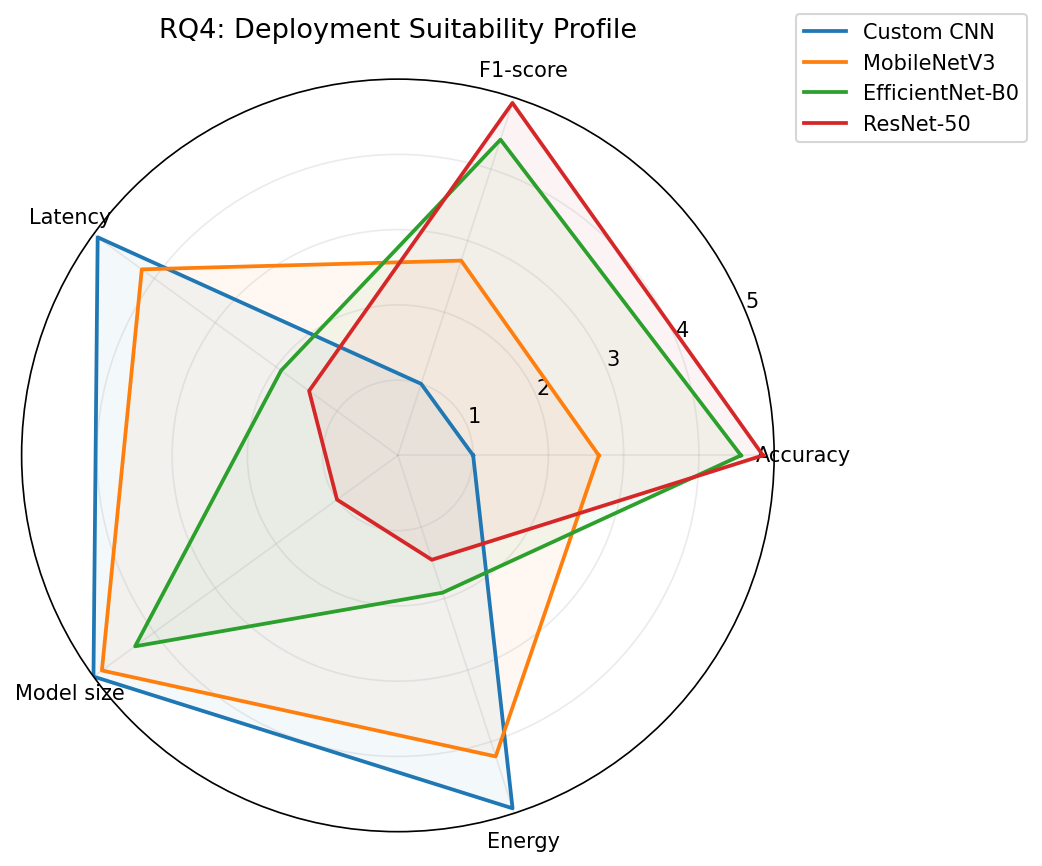

In [3]:

# ============================================================
# RQ4: Deployment Suitability
# ============================================================
# Research question:
# How does model complexity affect inference time and deployment suitability
# for real-world edge or mobile applications?
# ============================================================

results = load_or_run_results()

def score_higher_is_better(series):
    s = series.astype(float)
    if s.max() == s.min():
        return pd.Series([5.0] * len(s), index=s.index)
    return 1 + 4 * (s - s.min()) / (s.max() - s.min())

def score_lower_is_better(series):
    s = series.astype(float)
    if s.max() == s.min():
        return pd.Series([5.0] * len(s), index=s.index)
    return 1 + 4 * (s.max() - s) / (s.max() - s.min())

rq4_rows = []
for dataset_name, group in results.groupby("Dataset"):
    g = group.copy()
    g["Accuracy_Score"] = score_higher_is_better(g["Accuracy"])
    g["F1_Score"] = score_higher_is_better(g["F1_macro"])
    g["Latency_Score"] = score_lower_is_better(g["Latency_ms_per_image"])
    g["Size_Score"] = score_lower_is_better(g["Model_Size_MB"])
    g["Energy_Score"] = score_lower_is_better(g["Energy_per_image_mJ"])
    g["Deployment_Suitability_Score"] = g[
        ["Accuracy_Score", "F1_Score", "Latency_Score", "Size_Score", "Energy_Score"]
    ].mean(axis=1)
    rq4_rows.append(g)

rq4_full = pd.concat(rq4_rows, ignore_index=True)

rq4_table = rq4_full[[
    "Dataset", "Model", "Accuracy_Score", "F1_Score", "Latency_Score",
    "Size_Score", "Energy_Score", "Deployment_Suitability_Score"
]].copy()

rq4_table = rq4_table.sort_values(["Dataset", "Deployment_Suitability_Score"], ascending=[True, False])
rq4_csv = TABLE_DIR / "rq4_deployment_suitability.csv"
rq4_table.to_csv(rq4_csv, index=False)
print("Saved table:", rq4_csv)
display(rq4_table)

# Figure: radar chart using mean scores across both datasets
models = ["Custom CNN", "MobileNetV3", "EfficientNet-B0", "ResNet-50"]
radar_df = rq4_table.groupby("Model")[[
    "Accuracy_Score", "F1_Score", "Latency_Score", "Size_Score", "Energy_Score"
]].mean().reindex(models)

categories = ["Accuracy", "F1-score", "Latency", "Model size", "Energy"]
plot_cols = ["Accuracy_Score", "F1_Score", "Latency_Score", "Size_Score", "Energy_Score"]

N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(7.2, 7.2))
ax = plt.subplot(111, polar=True)

for model in models:
    values = radar_df.loc[model, plot_cols].values.tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=1.8, label=model)
    ax.fill(angles, values, alpha=0.05)

ax.set_title("RQ4: Deployment Suitability Profile", pad=20)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(["1", "2", "3", "4", "5"])
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.10), frameon=True)
save_current_figure("rq4_deployment_suitability_radar")


## Output locations

After running this notebook on Kaggle, check:

- Tables: `/kaggle/working/green_cv_results/tables/`
- Figures: `/kaggle/working/green_cv_results/figures/`
- Trained models: `/kaggle/working/green_cv_results/models/`

For IEEE/LaTeX papers, use the generated `.pdf` figure file.
